<br>

# 基于 PyTorch 实现循环神经网络

<br>

## 0. 概述

<br>

<font color=black size=3 face=雅黑>　　在本次实验中，我们将学习如何基于 PyTorch 构建循环神经网络 (Recurrent Neural Network，RNN)，并在实际任务中进行训练与测试。我们将使用两种循环神经网络并比较其效果，分别是基础版的 RNN 和长短期记忆网络 (Long Short-Term Memory Network, LSTM)。循环神经网络的最大特点即具有记忆能力。本次实验我们将分别利用循环神经网络处理分类问题（图像识别）和回归问题（预测 cosine 曲线），并观察其效果。
    
    
<br>

<font color=black size=3 face=雅黑>　　与上节课相同，对于一个分类或预测任务，我们将要进行的操作包括以下几点：

<font color=black size=3 face=雅黑>　　　1) 　读取和处理数据集
    
<font color=black size=3 face=雅黑>　　　2) 　定义一个包含可训练参数的神经网络
    
<font color=black size=3 face=雅黑>　　　3) 　从数据集中取出一个批次 (batch) 的样本传递给神经网络

<font color=black size=3 face=雅黑>　　　4) 　通过神经网络处理输入样本

<font color=black size=3 face=雅黑>　　　5) 　计算损失 (loss)

<font color=black size=3 face=雅黑>　　　6) 　反向传播计算偏导

<font color=black size=3 face=雅黑>　　　7) 　更新网络的参数
    
<font color=black size=3 face=雅黑>　　　8) 　重复 3) 到 7) 步，不断调整网络参数

<br>

<br>

<br>

## 1. 导入 PyTorch 和其他库

<br>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

In [2]:
print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())

torch.manual_seed(1)

2.9.0+cu126
0.24.0+cu126
True


<br>

## 2. 循环神经网络处理图像识别问题

<br>

<font color=black size=3 face=雅黑>　　在这一节中，我们将用循环神经网络（包括基础版的 RNN 和长短期记忆网络 LSTM）处理图像识别问题。采用的数据集依然是 CIFAR-10（32*32像素，RGB彩色图）。为了使用循环网络识别图片，我们将每张图片分割成若干部分（例如分割成 32 行），然后将每个部分顺序传递给网络进行训练。

<br>

### 2.1 数据集准备（CIFAR-10）

<br>

<font color=black size=3 face=雅黑>　　这一部分与之前的实验相同。
    
<br>

In [3]:
batch_size_train = 50  # 设置训练集和测试集的 batch size，即每批次将参与运算的样本数
batch_size_test = 100

# 训练集
train_set = torchvision.datasets.CIFAR10(root='./dataset_cifar10', train=True, download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(), 
                                            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
# 测试集
test_set = torchvision.datasets.CIFAR10(root='./dataset_cifar10', train=False, download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(), 
                                            torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size_test, shuffle=True)

<br>

### 2.2 构建一个基础的循环神经网络并训练

<br>



<font color=black size=3 face=雅黑>　　在这一节中，我们将使用 PyTorch 神经网络库 (torch.nn) 中的 nn.RNN 来构建一个最基础的循环神经网络。

   
<font color=black size=3 face=雅黑>　　关于 nn.RNN 的说明可见官方网址：https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN
    
<br>

In [4]:
time_step = 32  # 输入序列的长度 (此处设置为图片的行数)
input_size = 32*3  # 输入数据大小 (此处设置为图片每行的数据像素点个数*3通道)
hidden_size = 64  # 隐藏态（h_t）的特征长度
num_layers = 1  # 循环层个数

class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.rnn = nn.RNN(  # 使用普通 RNN
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # True：input & output 是以 batch size 为第一维度的特征集，input 的形状为 (batch, time_step, input_size)
        )

        ################### Please finish the following code ####################
               
        # 完成最后的全连接层，对图像进行分类：
        self.out = nn.Linear(hidden_size, 10)

        ################################ end ####################################

    def forward(self, x):
        # x：RNN 输入，形状为 (batch, time_step, input_size)
        # r_out：最后一个循环层在每个 t 时刻的输出特征 h_t ，形状为 (batch, time_step, output_size)
        # h_state：包含此 batch 中每层的最终隐藏态，形状为 (num_layers, batch, hidden_size)
        r_out, h_state = self.rnn(x, None)  # 初始的隐藏态设置为 None
        
        # 选取最后一个时间点的 r_out 输出（因为我们在读完一整张图后才做决定）
        # 这里 r_out[:, time_step-1, :] 的值也是 h_state[num_layers-1] 的值
        out = self.out(r_out[:, time_step-1, :])
        assert (r_out[:, time_step-1, :] == h_state[num_layers-1]).prod()
        
        return out

In [5]:
rnn = RNN()
# rnn.cuda()
print(rnn)

RNN(
  (rnn): RNN(96, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


In [6]:
def get_num_correct(preds, labels):
    return preds.argmax(dim=1).eq(labels).sum().item()

<br>

<font color=black size=3 face=雅黑>开始训练：

<br>

In [7]:
epochs = 4  # 训练周期
lr = 0.002  # 学习率（learning rate）

loss_func = nn.CrossEntropyLoss()  # 损失函数
optimizer = torch.optim.Adam(rnn.parameters(), lr=lr)  # 优化器

for epoch in range(epochs):
    
    total_loss = 0
    total_train_correct = 0
    
    for step, batch in enumerate(train_loader):
        images, labels = batch
        # images = images.cuda()
        # labels = labels.cuda()
        
        # 首先按照网络模型的要求，对 image 进行 reshape
        images = images.view(batch_size_train, time_step, input_size)

        ################### Please finish the following code #################### 


        # 接下来，请完成正向传播、反向传播和参数更新
        preds = rnn(images)
        loss = loss_func(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ################################ end ####################################
 
        total_loss += loss.item()
        total_train_correct += get_num_correct(preds, labels)
        
    print(f"epoch[{epoch}] \t loss: {total_loss} \t training accuracy: {total_train_correct/len(train_set)*100}%")

epoch[0] 	 loss: 1932.807561635971 	 training accuracy: 29.896%
epoch[1] 	 loss: 1792.029673218727 	 training accuracy: 34.966%
epoch[1] 	 loss: 1792.029673218727 	 training accuracy: 34.966%
epoch[2] 	 loss: 1743.704416513443 	 training accuracy: 36.718%
epoch[2] 	 loss: 1743.704416513443 	 training accuracy: 36.718%
epoch[3] 	 loss: 1715.1337121725082 	 training accuracy: 37.74%
epoch[3] 	 loss: 1715.1337121725082 	 training accuracy: 37.74%


<br>

<font color=black size=3 face=雅黑>测试训练好的神经网络：

<br>

In [8]:
num_correct = 0
rnn.cpu()  # 注意：模型被移至 CPU

for idx, batch in enumerate(test_loader):
   
    images, labels = batch
    images = images
    labels = labels
    images = images.reshape(batch_size_test, time_step, input_size)  # 注意调整 images 的形状
    
    ################### Please finish the following code #################### 
    
    # 请完成测试，并统计分类正确的次数（num_correct）    
    with torch.no_grad():
        preds = rnn(images)
    num_correct += get_num_correct(preds, labels)
    
    ################################ end ####################################
       
    if idx==0:
        print("preds.shape: ", preds.shape)  # 检查 pred 的形状
        pred_labels = torch.max(preds, dim=1)[1].data.numpy().squeeze()  # 得到全部测试样本的分类结果
        print("pred_labels.shape: ", pred_labels.shape)
        print("predicted labels (first 10 samples): ", pred_labels[:10])  # 打印前 10 个样本的分类结果
        print("real labels (first 10 samples): ", labels[:10])  # 打印前 10 个样本的分类结果

preds.shape:  torch.Size([100, 10])
pred_labels.shape:  (100,)
predicted labels (first 10 samples):  [1 3 7 1 3 5 5 6 1 9]
real labels (first 10 samples):  tensor([1, 2, 7, 6, 7, 6, 0, 6, 9, 9])


<br>

<font color=black size=3 face=雅黑>得到测试准确率：

<br>

In [9]:
test_accuracy = num_correct/len(test_set)

print("test accuracy: ", test_accuracy)

test accuracy:  0.3777


<br>

<font color=black size=3 face=雅黑>对于输入序列的每个元素，每一层都将进行如下运算：

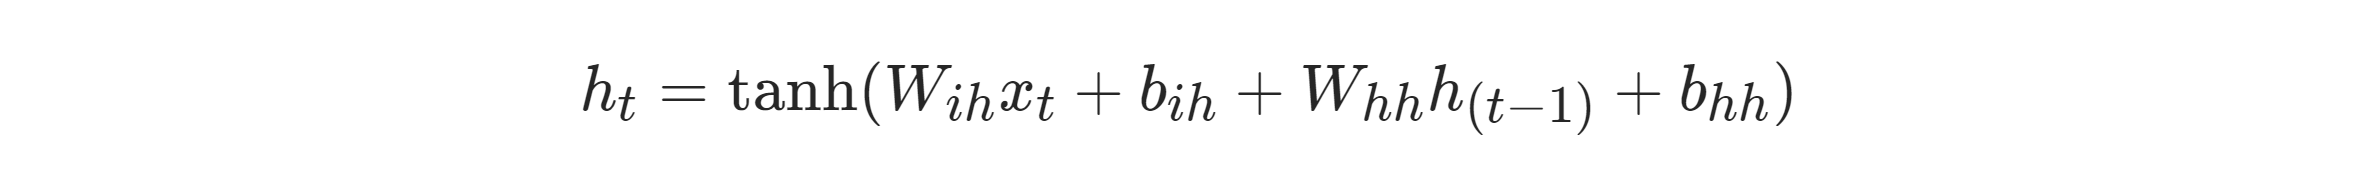
    
<font color=black size=3 face=雅黑>其中，$h_t$ 是 $t$ 时刻的隐藏态 (hidden state)，$x_t$ 是 $t$ 时刻的网络输入，$h_{t-1}$ 是 $t-1$ 时刻的隐藏态或网络的初始隐藏态。
    
<br>

<font color=black size=3 face=雅黑>**已知这里遇到了长程依赖问题，请思考如何通过修改 RNN 的输入序列，使得模型准确度上升？(【提示】需要同时修改 time_step 和 input_size 两个变量，由于每个图片大小是 32 * 32 * 3，要注意这里两个变量乘积要保持始终 32 * 32 * 3。) 在实验报告中展示修改后的代码和训练/测试结果，并讨论其原因。**

<br>

<br>

### 2.3 改进：重新构建一个 LSTM 网络并训练

<br>

<font color=black size=3 face=雅黑>　　除了修改 RNN 的输入，另一个有效提高训练效果的方法即使用 LSTM 取代基础的 RNN 结构。
    
<font color=black size=3 face=雅黑>　　关于 nn.LSTM 的说明可见官方网址：https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html#torch.nn.LSTM
    
<br>

In [10]:
time_step = 32*3  # 输入序列的长度 (此处设置为图片的行数)
input_size = 32  # 输入数据大小 (此处设置为图片每行的数据像素点个数)
hidden_size = 64  # 隐藏态（h_t）的特征数
num_layers = 1  # 循环层个数

class LSTM(nn.Module):
    def __init__(self):
        super(LSTM, self).__init__()

        self.lstm = nn.LSTM(  # 使用 LSTM
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers, 
            batch_first=True,  # True：input & output 是以 batch size 为第一维度的特征集，input 的形状为 (batch, time_step, input_size)
        )

        ################### Please finish the following code ####################
 
        # 完成最后的全连接层，对图像进行分类：  
        self.out = nn.Linear(hidden_size, 10)
        
        ################################ end ####################################


    def forward(self, x):
        # x：网络输入，形状为 (batch, time_step, input_size)
        # r_out：最后一个循环层在每个 t 时刻的输出特征 h_t ，形状为 (batch, time_step, output_size)
        # h_n：包含此 batch 中每层的最终隐藏态 (hidden state)，形状为 (num_layers, batch, hidden_size)
        # h_c：包含此 batch 中每层最终细胞状态 (cell state)，形状为 (num_layers, batch, hidden_size)
        r_out, (h_n, h_c) = self.lstm(x, None)   # 初始隐藏态及细胞状态设为 (h0, c0) = None
        
        # 选取最后一个时间点的 r_out 输出（因为我们在读完一整张图才开始做决定）
        # 这里 r_out[:, time_step-1, :] 的值也是 h_n[num_layers-1] 的值
        out = self.out(r_out[:, time_step-1, :])
        assert (r_out[:, time_step-1, :] == h_n[num_layers-1]).prod()
        
        return out

In [11]:
lstm = LSTM()
lstm.cuda()
print(lstm)

LSTM(
  (lstm): LSTM(32, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


In [12]:
def get_num_correct(preds, labels):
    return preds.argmax(dim=1).eq(labels).sum().item()

<br>

<font color=black size=3 face=雅黑>开始训练：

<br>

In [13]:
epochs = 4  # 训练周期
lr = 0.001  # 学习率（learning rate）

loss_func = nn.CrossEntropyLoss()  # 损失函数
optimizer = torch.optim.Adam(lstm.parameters(), lr=lr)  # 优化器

for epoch in range(epochs):
    
    total_loss = 0
    total_train_correct = 0
    
    for step, batch in enumerate(train_loader):
   
        images, labels = batch
        images = images.cuda()
        labels = labels.cuda()
        images = images.view(batch_size_train, time_step, input_size)  # 注意调整 images 的形状

        ################### Please finish the following code #################### 
        
        # 请完成正向传播、反向传播、参数更新的相关代码  
        preds = lstm(images)
        loss = loss_func(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ################################ end ####################################

        total_loss += loss.item()
        total_train_correct += get_num_correct(preds, labels)
        
    print(f"epoch[{epoch}]:  loss: {total_loss}  accuracy: {total_train_correct/len(train_set)*100}%")

epoch[0]:  loss: 1965.1076604127884  accuracy: 27.46%
epoch[1]:  loss: 1756.6726846694946  accuracy: 36.006%
epoch[1]:  loss: 1756.6726846694946  accuracy: 36.006%
epoch[2]:  loss: 1664.1430580615997  accuracy: 39.566%
epoch[2]:  loss: 1664.1430580615997  accuracy: 39.566%
epoch[3]:  loss: 1594.480817914009  accuracy: 42.234%
epoch[3]:  loss: 1594.480817914009  accuracy: 42.234%


<br>

<font color=black size=3 face=雅黑>测试训练好的神经网络：

<br>

In [14]:
lstm.cpu()  # 注意：模型被移至 CPU

num_correct = 0

for idx, batch in enumerate(test_loader):
       
    images, labels = batch
    images = images
    labels = labels
    images = images.reshape(batch_size_test, time_step, input_size)  # 注意调整 images 的形状
    
    ################### Please finish the following code #################### 
    
    # 请完成测试，并统计分类正确的次数（num_correct）
    with torch.no_grad():
        preds = lstm(images)
    num_correct += get_num_correct(preds, labels)

    ################################ end ####################################
    
    if idx == 0:
        print("preds.shape: ", preds.shape)
        preds_labels = torch.max(preds, 1)[1].data.numpy().squeeze()  # 得到全部测试样本的分类结果
        print("preds_labels.shape: ", preds_labels.shape)
        print("predicted labels (first 10 samples): ", preds_labels[:10])  # 打印前 10 个样本的分类结果
        print("real labels (first 10 samples): ", labels[:10])  # 打印前 10 个样本的分类结果

preds.shape:  torch.Size([100, 10])
preds_labels.shape:  (100,)
predicted labels (first 10 samples):  [9 8 8 4 7 3 9 0 7 3]
real labels (first 10 samples):  tensor([9, 0, 8, 4, 7, 3, 9, 4, 7, 2])


<br>

<font color=black size=3 face=雅黑>得到测试准确率：

<br>

In [15]:
test_accuracy = num_correct/len(test_loader)

print("test accuracy: ", test_accuracy)

test accuracy:  43.13


<br>

<font color=black size=3 face=雅黑>**LSTM 网络和基础版的 RNN 相比训练效果如何？造成差异的原因是什么？请在实验报告中展示结果并讨论。**

<br>

<br>

<font color=black size=3 face=雅黑>对于输入序列的每个元素，每一层都将进行如下运算 (见 nn.LSTM 官方文档)：

<br>
    
<font color=black size=3 face=雅黑>　　　$i_t = \sigma(W_{ii}x_{t} + b_{ii} + W_{hi}h_{t-1} + b_{hi})$
    
<font color=black size=3 face=雅黑>　　　$f_t = \sigma(W_{if}x_{t} + b_{if} + W_{hf}h_{t-1} + b_{hf})$
    
<font color=black size=3 face=雅黑>　　　$g_t = tanh(W_{ig}x_{t} + b_{ig} + W_{hg}h_{t-1} + b_{hg})$

<font color=black size=3 face=雅黑>　　　$o_t = \sigma(W_{io}x_{t} + b_{io} + W_{ho}h_{t-1} + b_{ho})$
    
<font color=black size=3 face=雅黑>　　　$c_t = f_{t}\bigodot c_{t-1} + i_{t}\bigodot g_{t}$
    
<font color=black size=3 face=雅黑>　　　$h_t = o_{t}\bigodot tanh(c_{t})$
    
<br>
    
<font color=black size=3 face=雅黑>其中，$h_t$ 是 $t$ 时刻的隐藏态 (hidden state)，$c_t$ 是 t 时刻的细胞状态 (cell state)，$x_t$ 是 $t$ 时刻的网络输入，$h_{t-1}$ 是 $t-1$ 时刻的隐藏态或网络的初始隐藏态。 $i_t$、$f_t$、$g_t$、$o_t$ 则分别是输入门 (input gate)、遗忘门 (forget gate)、候选状态和输出门 (output gate)。
    
<br>

<br>

## 3. 循环神经网络处理回归问题

<br>

<font color=black size=3 face=雅黑>　　在这一节中，我们将用循环神经网络处理回归问题。其中神经网络的输入 $x$ 为一条 $sin$ 曲线（横轴：时间；纵轴：$x$）。我们将训练一个循环网络，根据输入 $x$ 预测输出值 $y$，$y$ 的预期值是一条 $cos$ 曲线。
    
<br>

<font color=black size=3 face=雅黑>　　为了帮助大家理解，我们首先来画出输入 x 和预期输出 y：
    
<br>

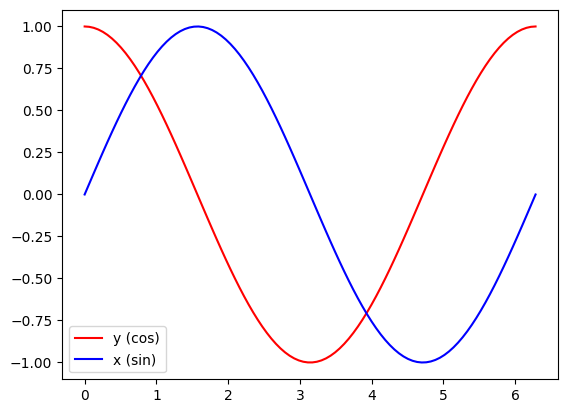

In [16]:
steps = np.linspace(0, 2*np.pi, 100, dtype=np.float32)  # 横轴（时间）
x_np = np.sin(steps)  # 网络输入
y_np = np.cos(steps)  # 预期输出

# 绘图 （蓝色线：网络输入 x；红色线：预期输出 y）
plt.plot(steps, y_np, 'r-', label="y (cos)")
plt.plot(steps, x_np, 'b-', label="x (sin)")
plt.legend(loc='best')
plt.show()

<br>

<font color=black size=3 face=雅黑>定义循环神经网络 RNN2：
    
<br>

In [17]:
time_step = 10  # 输入序列的长度
input_size = 1  # 输入数据大小（在这个问题中，横轴上一个时间点对应一个数据，因此 input_size 取 1）
hidden_size = 32  # 隐藏态（h_t）的特征数
num_layers = 1  # 循环层个数

In [ ]:
class RNN2(nn.Module):
    def __init__(self):
        super(RNN2, self).__init__()

        self.rnn = nn.RNN(  # 基础的 RNN 就足以满足本次任务
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        ################### Please finish the following code ####################
        
        # 请完成最后的全连接层，对图像进行分类        
        self.out = nn.Linear(hidden_size, 1)
        
        ################################ end ####################################
        
    def forward(self, x, h_state):
        # x：网络输入，形状为 (batch, time_step, input_size)
        # r_out：最后一个循环层在每个 t 时刻的输出特征 h_t ，形状为 (batch, time_step, output_size)     
        # h_state：包含此 batch 中每个元素的最终隐藏状态，形状为 (num_layers, batch, hidden_size)   
        # r_out, h_state = self.rnn(x, None)
        r_out, h_state = self.rnn(x, h_state)
              
        outs = []  # 回归问题：保存所有时间点的预测值
        for time_step in range(r_out.size(1)):  # 逐一对每个时间点计算 output
            outs.append(self.out(r_out[:, time_step, :]))
        
        return torch.stack(outs, dim=1), h_state

In [19]:
rnn2 = RNN2()
print(rnn2)

RNN2(
  (rnn): RNN(1, 32, batch_first=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)


<br>

<font color=black size=3 face=雅黑>开始训练：
    
<br>

In [ ]:
lr = 0.02  # 学习率
iterations = 100  # 迭代次数

optimizer = torch.optim.Adam(rnn2.parameters(), lr=lr)  # 优化器
loss_func = nn.MSELoss()  # 损失函数：均方误差

h_state = None  # 初始的隐藏态可以设成 None
entire_preds = []  # 记录预测结果，用于作图

for step in range(iterations):
    
    # 准备数据
    start, end = step * np.pi, (step+1)*np.pi  # 每次取一个 np.pi 的范围
    steps = np.linspace(start, end, time_step, dtype=np.float32)  # 序列长度：time_step
    x_np = np.sin(steps)  # 输入值
    y_np = np.cos(steps)  # 预期输出值

    # 输入数据：形状 (batch, time_step, input_size)，其中 batch=1，input_size=1
    x = torch.from_numpy(x_np[np.newaxis, :, np.newaxis])
    
    # 预期输出：形状 (batch, time_step, 网络的最终输出维度)，其中 batch=1，网络的最终输出维度=1
    y = torch.from_numpy(y_np[np.newaxis, :, np.newaxis])

    # 正向传播
    preds, h_state = rnn2(x, h_state)
    h_state = h_state.data  # 把 h_state 重新包装一下放入下一个 iteration
    
    ################### Please finish the following code #################### 
    
    # 计算损失
    #loss = XXX
    
    # 反向传播并更新参数
    # XXX
    # XXX
    # XXX
    
    #################################### end #################################
    
    preds_plot = preds.detach().clone()  # shape: (batch, time_step, 网络的最终输出维度)
    entire_preds.append(preds_plot)
    

<br>

<font color=black size=3 face=雅黑>下面我们将训练过程中的实际输出作图与预期输出相比较：
    
<br>

entire_preds.shape:  torch.Size([100, 1, 10, 1])
第一段：(前 1/4 的 iterations)


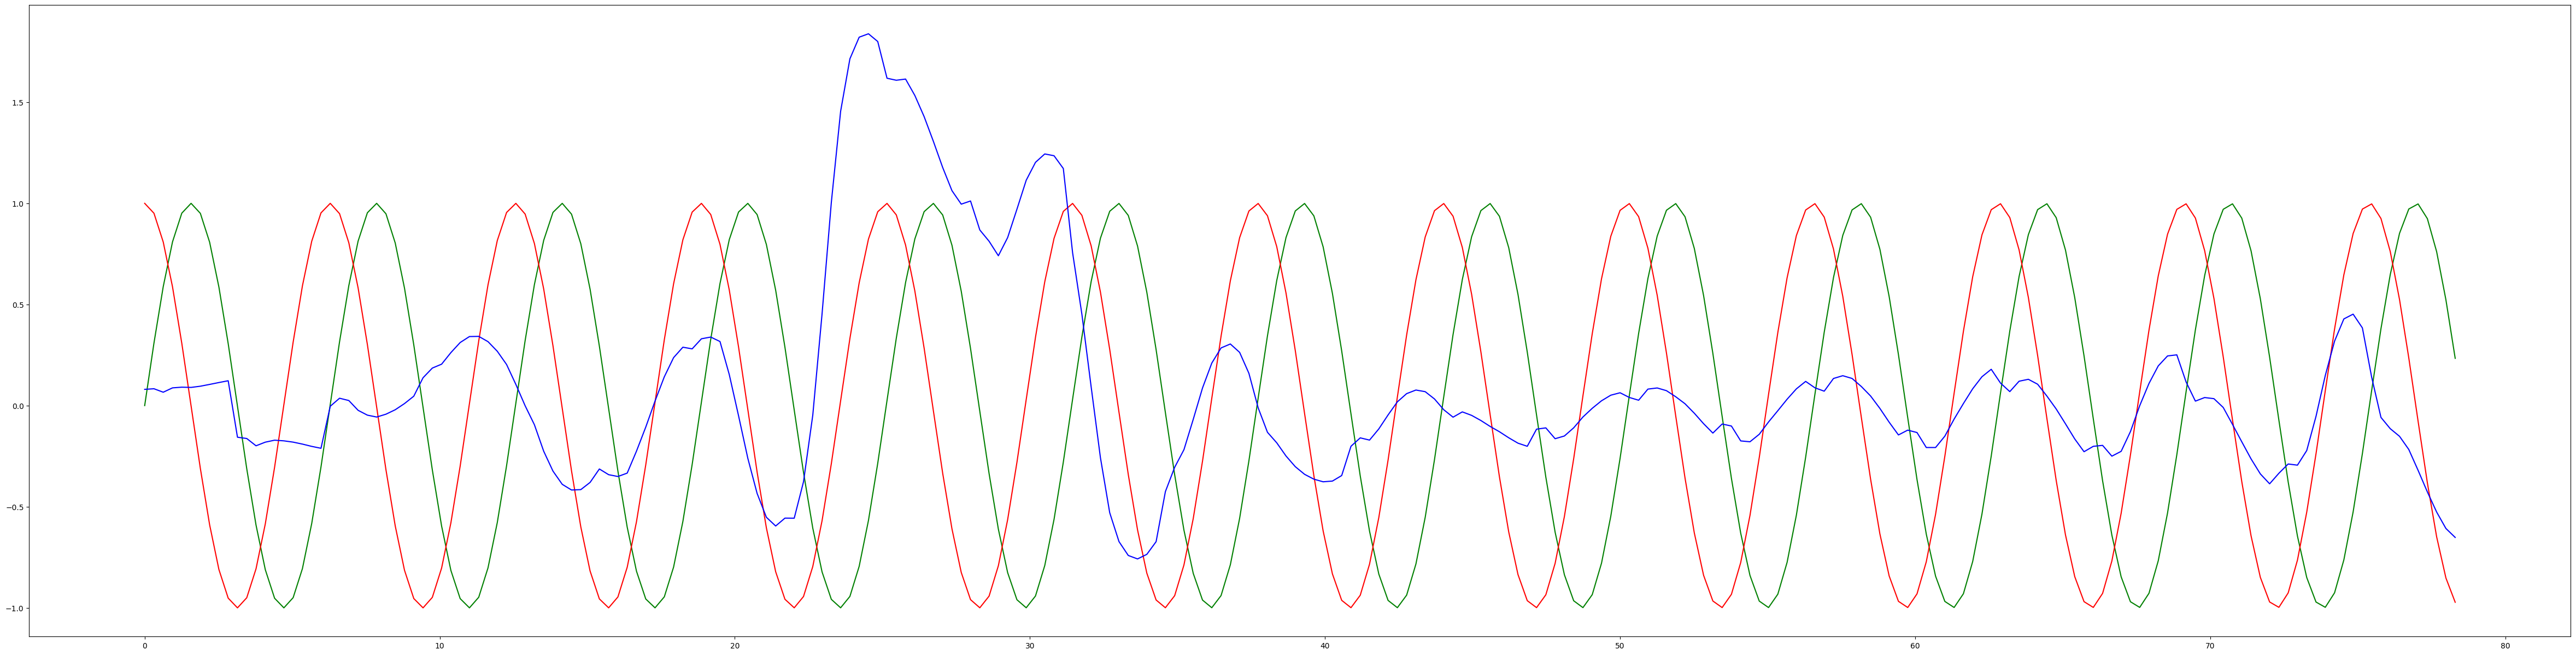

第二段：


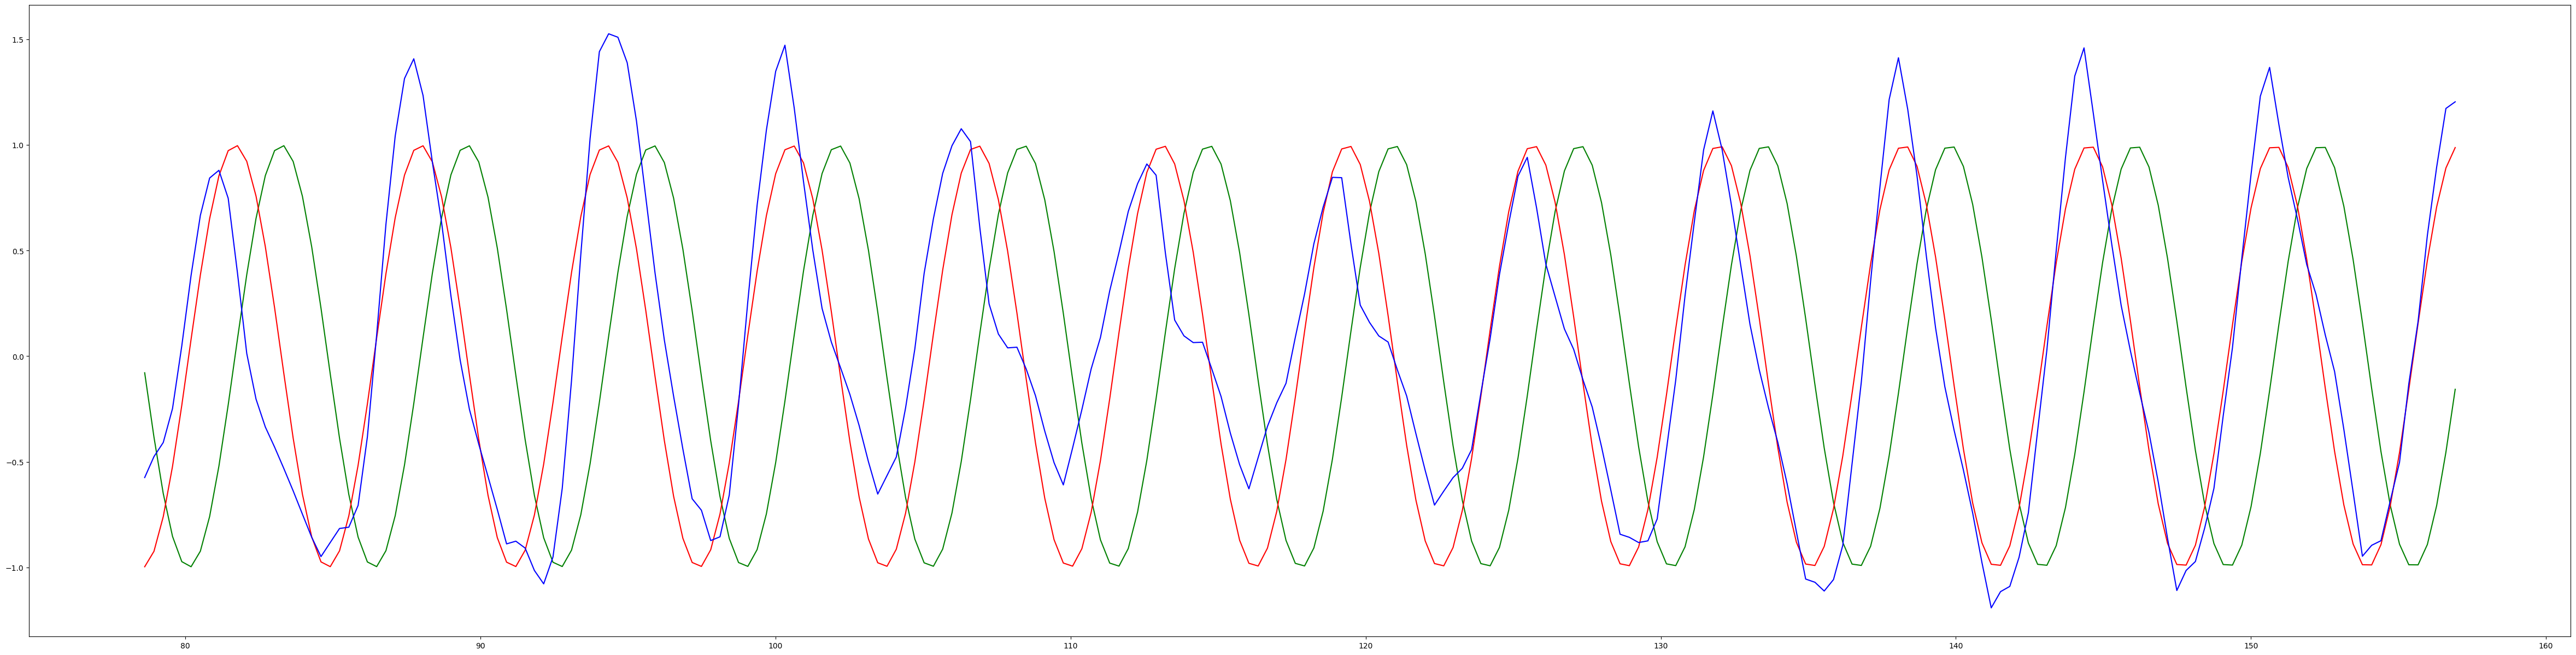

第三段：


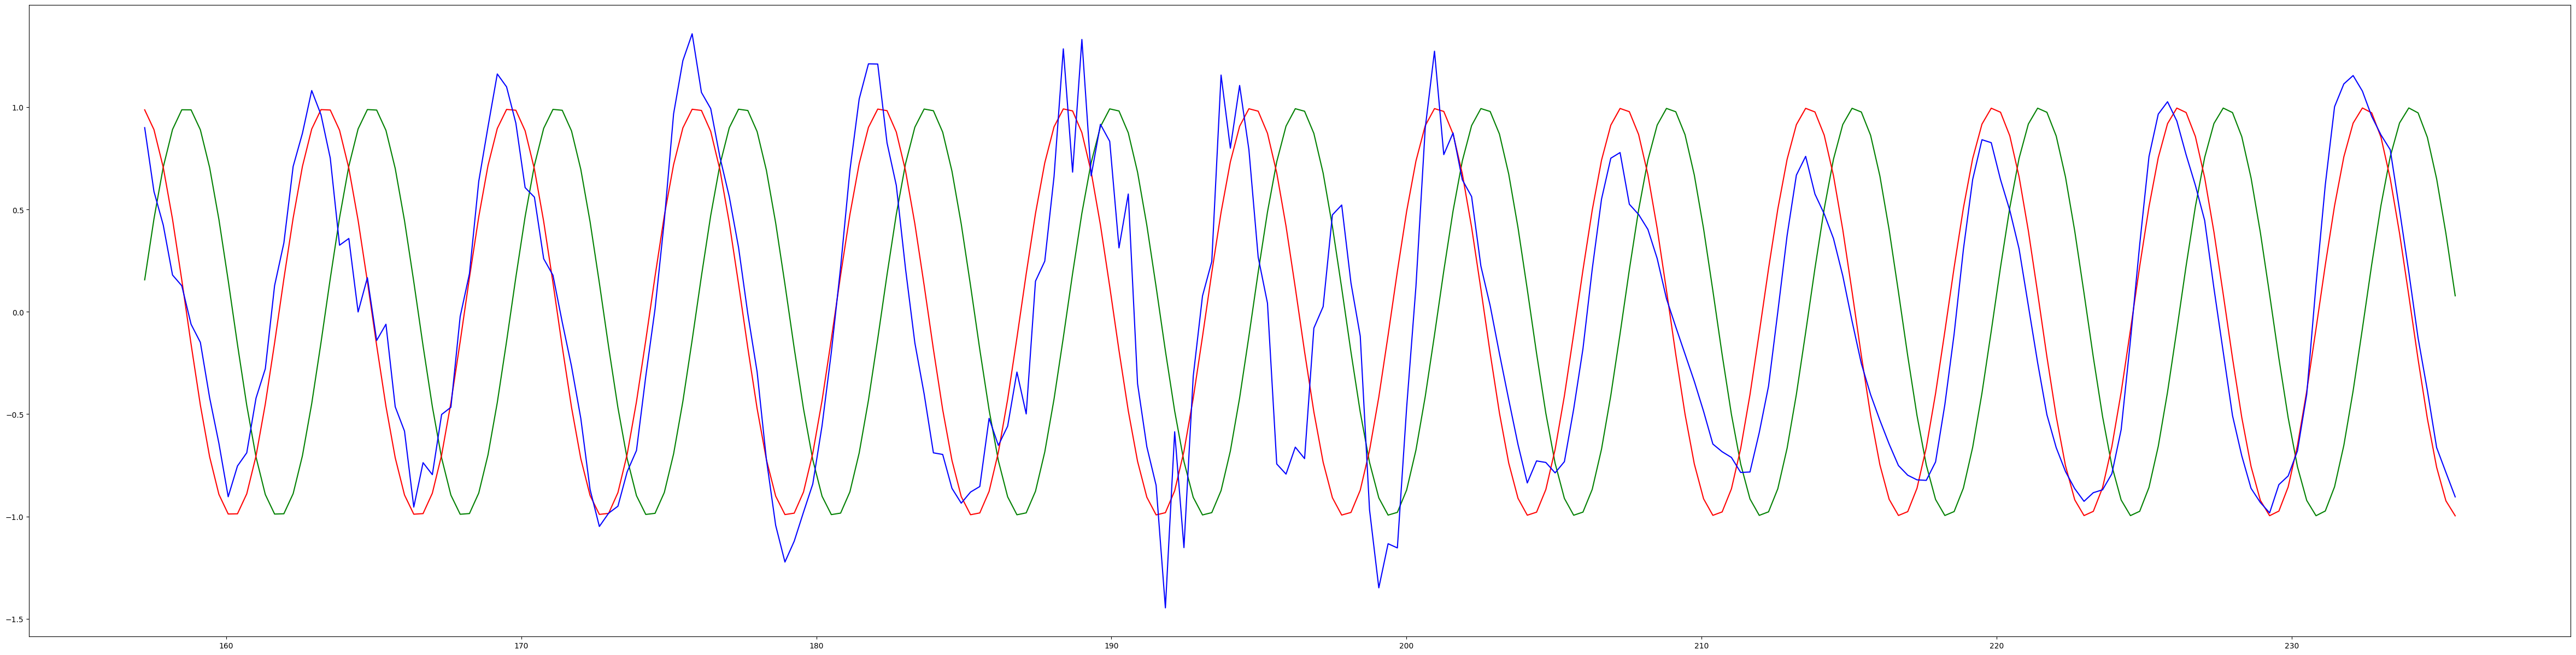

第四段：


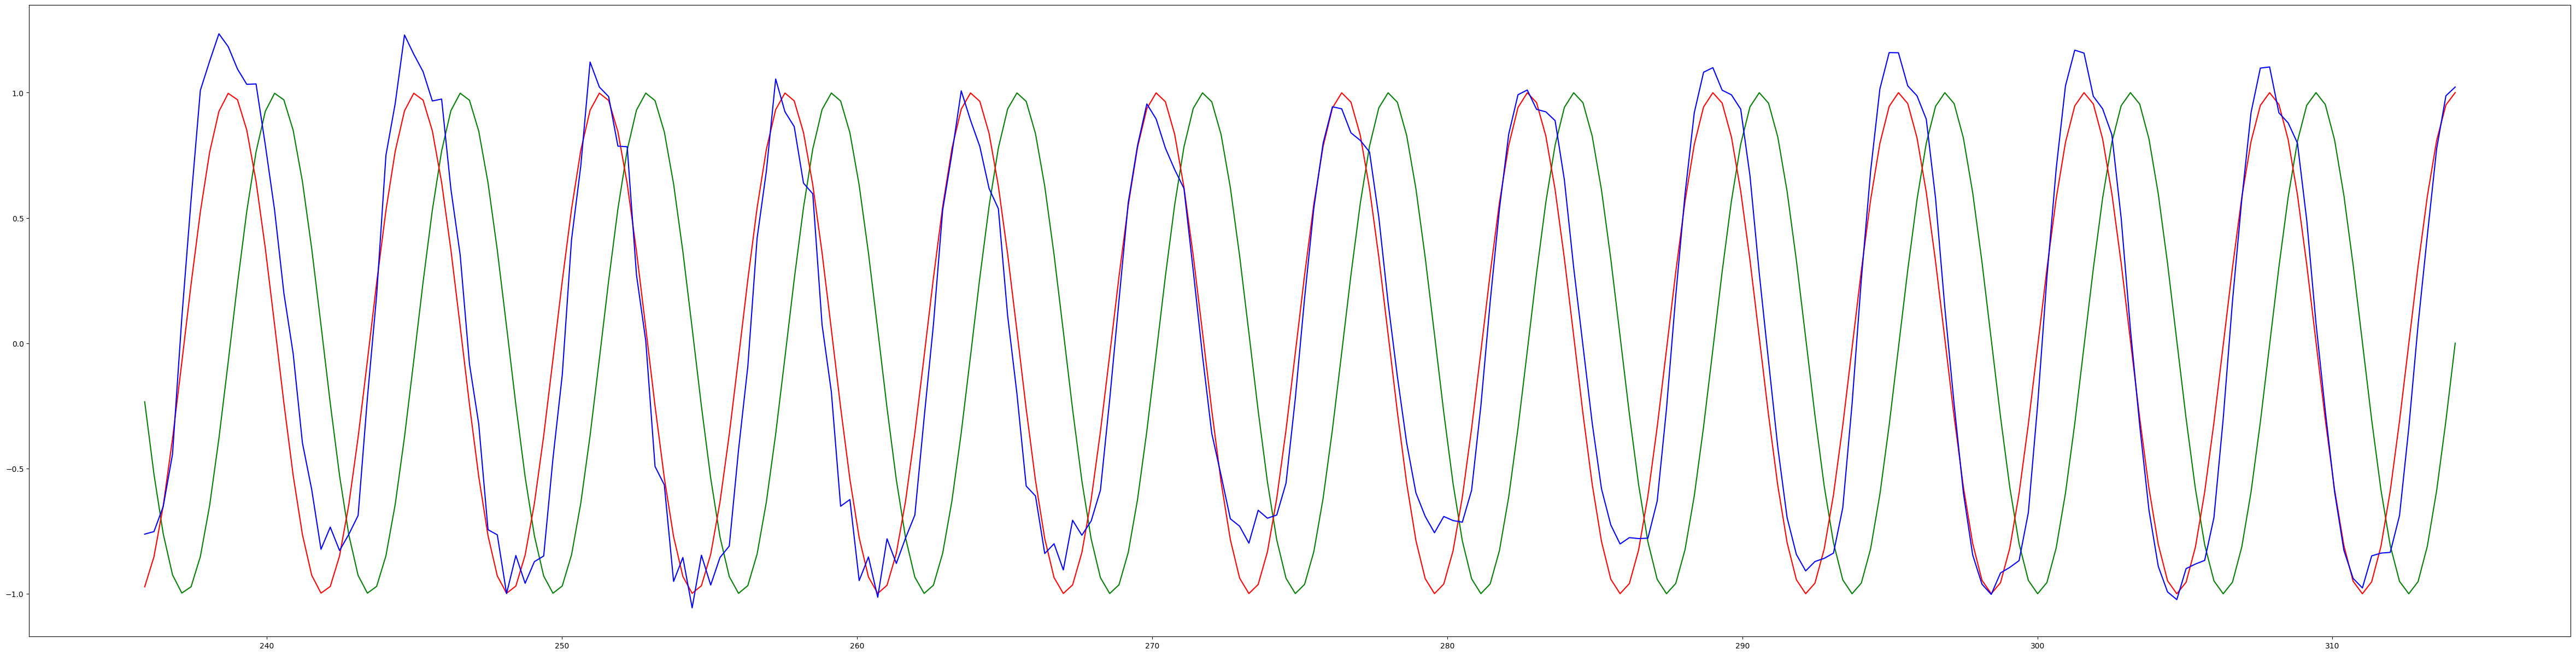

In [21]:
entire_preds = torch.stack(entire_preds, dim=0)
print("entire_preds.shape: ", entire_preds.shape)  # (iterations, batch, time_step, 网络的最终输出维度)
entire_preds = entire_preds.reshape(iterations*time_step)

entire_steps = np.linspace(0, iterations*np.pi, iterations*time_step, dtype=np.float32)  # 整个横轴（时间）
entire_x = np.sin(entire_steps)  # 完整的网络输入，长度: iterations*time_step
entire_y = np.cos(entire_steps)  # 完整的网络预期输出，长度: iterations*time_step


seg = int(iterations*time_step/4)  # 为了方便作图比较，下面我们将整个图分作四段画出

print("第一段：(前 1/4 的 iterations)")  # 第一段图 iteration 0-24，250个样本点
plt.figure(figsize=(60,15))
plt.plot(entire_steps[0:seg], entire_x[0:seg], 'g-', label="input")
plt.plot(entire_steps[0:seg], entire_y[0:seg], 'r-', label="target output")
plt.plot(entire_steps[0:seg], entire_preds.numpy()[0:seg], 'b-', label="real output")
plt.show()

print("第二段：")  # 第二段图 iteration 25-49，250个样本点
plt.figure(figsize=(60,15))
plt.plot(entire_steps[seg:seg*2], entire_x[seg:seg*2], 'g-', label="input")
plt.plot(entire_steps[seg:seg*2], entire_y[seg:seg*2], 'r-', label="target output")
plt.plot(entire_steps[seg:seg*2], entire_preds.numpy()[seg:seg*2], 'b-', label="real output")
plt.show()

print("第三段：")  # 第三段图 iteration 50-74，250个样本点
plt.figure(figsize=(60,15))
plt.plot(entire_steps[seg*2:seg*3], entire_x[seg*2:seg*3], 'g-', label="input")
plt.plot(entire_steps[seg*2:seg*3], entire_y[seg*2:seg*3], 'r-', label="target output")
plt.plot(entire_steps[seg*2:seg*3], entire_preds.numpy()[seg*2:seg*3], 'b-', label="real output")
plt.show()

print("第四段：")  # 第四段图 iteration 75-99，250个样本点
plt.figure(figsize=(60,15))
plt.plot(entire_steps[seg*3:seg*4], entire_x[seg*3:seg*4], 'g-', label="input")
plt.plot(entire_steps[seg*3:seg*4], entire_y[seg*3:seg*4], 'r-', label="target output")
plt.plot(entire_steps[seg*3:seg*4], entire_preds.numpy()[seg*3:seg*4], 'b-', label="real output")
plt.show()

<br>

<font color=black size=3 face=雅黑>从上图中可以看出，预测的效果并不是很好。这是因为 RNN2 的 forward 函数有一行代码存在问题：

<font color=black size=3 face=雅黑>　　r_out, h_state = self.rnn(x, None)

<br>

<font color=black size=3 face=雅黑>**请修改这行代码，在实验报告中展示修改后的代码及训练结果，并说明原因。（[提示]：需要用上一轮的输出变量值 h_state 取代 None）**
    
<br>

<br>

# 4.  实验报告

<br>

<font color=black size=3 face=雅黑>请同学们在实验报告中完成如下内容：
    
<br>
  
<font color=black size=3 face=雅黑>**“2_pytorch_rnn.ipynb”**：

<br>
    
<font color=black size=3 face=雅黑>　　-　2.2 构建一个基础的循环神经网络并训练
    
<font color=black size=3 face=雅黑>　　　　请同学们补全代码，展示训练及测试结果。
     
<font color=black size=3 face=雅黑>　　　　请思考如何通过修改 RNN 的输入，使得模型准确度上升？在实验报告中展示修改后的代码和训练结果，并讨论原因。
    
<br>
    
<font color=black size=3 face=雅黑>　　-　2.3 改进：重新构建一个 LSTM 网络并训练
    
<font color=black size=3 face=雅黑>　　　　请同学们补全代码，展示训练及测试结果，并和基础版的 RNN 比较。
       
<br> 
    
<font color=black size=3 face=雅黑>　　-　3. 循环神经网络处理回归问题
    
<font color=black size=3 face=雅黑>　　　　请同学们补全代码，展示训练结果（该训练结果一开始并不理想）。
    
<font color=black size=3 face=雅黑>　　　　如上所述，RNN2 的 forward 函数有一行代码存在问题。请修改它，在实验报告中展示修改后的代码及训练结果，并说明原因。
    
<br> 
<br>    